In [2]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

np.random.seed(0)

## Data processing

In [3]:
def load_data(binary=False):
    df_white = pd.read_csv("winequality-white.csv")
    df_red = pd.read_csv("winequality-red.csv")
    data_white = np.array([row.split(';') for row in df_white.iloc[:, 0].values])
    data_red = np.array([row.split(';') for row in df_red.iloc[:, 0].values])

    data = np.concatenate((data_white, data_red))
    
    X = data[:, :-1].astype('double')
    y = data[:, -1].astype('int')

    if binary:
        y = np.where(y > 5, 1, -1)

    # Shuffle
    indices = np.random.permutation(X.shape[0])
    X = X[indices]
    y = y[indices]

    # Split training set and test set
    Xtrain = X[:4800]   # dimension: 4800 x 11
    Xtest = X[4800:]    # dimension: 1697 x 11
    ytrain = y[:4800]   # dimension: 4800 x 1
    ytest = y[4800:]    # dimension: 1697 x 1

    # Normalization
    mu, sigma = Xtrain.mean(axis=0), Xtrain.std(axis=0)
    Xtrain = (Xtrain - mu) / sigma
    Xtest = (Xtest - mu) / sigma

    # Print data info
    print("Number of training samples: %d, number of test samples: %d" %(len(ytrain), len(ytest)))
    unique, counts = np.unique(ytrain, return_counts=True)
    print("Labels: ", unique)
    print("Number of training samples in each class:")
    print(counts)
    print()

    return Xtrain, ytrain, Xtest, ytest


## Binary SVM class

In [4]:
class SVM:
    def __init__(self, C=1.0, learning_rate=0.1, max_iter=1000, batch_size=64):
        self.C = C
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.batch_size = batch_size
        self.w = None  # Initialize weights to zeros (11 features)
        self.b = None
        self.clf_soft = None

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.w = np.zeros(n_features)
        self.b = 0.0

        for i in range(self.max_iter):
            # Shuffle to remove bias
            indices = np.random.permutation(n_samples)

            for start in range(0, n_samples, self.batch_size):
                batch_indices = indices[start:start + self.batch_size]

                X_batch = X[batch_indices]
                y_batch = y[batch_indices]

                # Compute y_i(w^T x_i + b)
                margins = y[batch_indices] * (X_batch @ self.w + self.b)

                violated = margins < 1 # only update if it is violated

                batch_size = len(batch_indices)

                dw = self.w - (self.C / batch_size) * (X_batch[violated].T @ y_batch[violated])
                db = - (self.C / batch_size) * np.sum(y_batch[violated])

                self.w -= self.learning_rate * dw
                self.b -= self.learning_rate * db

        return self
    
    def predict(self, X):
        scores = X @ self.w + self.b
        return np.where(scores >= 0, 1, -1)

Xtrain, ytrain, Xtest, ytest = load_data(binary=True)
binary_svm = SVM(C=1.0, learning_rate=0.1, max_iter=1000, batch_size=64)
binary_svm.fit(Xtrain, ytrain)



Number of training samples: 4800, number of test samples: 1697
Labels:  [-1  1]
Number of training samples in each class:
[1780 3020]



## Plots for binary SVM

In [7]:
def plot(Xtrain, ytrain, Xtest, ytest):

    C_values = [0.01, 1, 100, 10000, 1000000]

    train_acc = []
    test_acc = []
    margins = []

    for C in C_values:

        clf = SVM(
            C=C,
            learning_rate=0.1,
            max_iter=1000,
            batch_size=64
        )

        clf.fit(Xtrain, ytrain)

        # Accuracy
        train_acc.append(
            np.mean(ytrain == clf.predict(Xtrain))
        )

        test_acc.append(
            np.mean(ytest == clf.predict(Xtest))
        )

        # Margin
        norm_w = np.linalg.norm(clf.w)

        margin = 2 / norm_w if norm_w > 0 else np.inf
        margins.append(margin)

        print(
            "C = %-9g train acc = %.4f  test acc = %.4f  margin = %.4f"
            % (C, train_acc[-1], test_acc[-1], margins[-1])
        )

    # Accuracy vs C
    plt.figure()

    plt.plot(
        C_values,
        train_acc,
        'o-',
        label='Training accuracy'
    )

    plt.plot(
        C_values,
        test_acc,
        's-',
        label='Test accuracy'
    )

    plt.xscale('log')
    plt.xlabel('C (log scale)')
    plt.ylabel('Accuracy')
    plt.title('SVM accuracy vs regularization parameter C')
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)

    plt.savefig(
        'accuracy_vs_C.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.close()

    # Margin vs C
    plt.figure()

    plt.plot(
        C_values,
        margins,
        'o-'
    )

    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel('C (log scale)')
    plt.ylabel(r'Margin $2 / \|w\|$')
    plt.title('SVM margin vs regularization parameter C')

    plt.grid(True, which='both', alpha=0.3)

    plt.savefig(
        'margin_vs_C.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.close()    # Note: plt.show() is deliberately NOT called here. It blocks until the
    # figure windows are closed, which would stall the rest of main.
plot(Xtrain, ytrain, Xtest, ytest)

C = 0.01      train acc = 0.6292  test acc = 0.6441  margin = 1172.2180
C = 1         train acc = 0.6321  test acc = 0.6458  margin = 9.9057
C = 100       train acc = 0.5965  test acc = 0.5981  margin = 0.4073
C = 10000     train acc = 0.6585  test acc = 0.6547  margin = 0.0053
C = 1e+06     train acc = 0.6725  test acc = 0.6606  margin = 0.0000


## Multi-class SVM

In [14]:
class MultiClassSVM:
    def __init__(self, C=1.0, learning_rate=0.1, max_iter=1000, batch_size=64):
        self.labels = None
        self.classifiers = None
        self.C = C
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.batch_size = batch_size

    def fit(self, X, y):
        self.labels = np.unique(y)
        # labels now has something like [3, 4, 5, ..]
        self.classifiers = []

        for label in self.labels:
            binary_y = np.where(y == label, 1, -1) # forcing it to either +1 or -1
            clf = SVM(
                self.C,
                learning_rate = self.learning_rate,
                max_iter = self.max_iter,
                batch_size = self.batch_size
            )

            # train using the original features and the new binary labels
            clf.fit(X, binary_y)

            # store the values of w* and b* for that particular classifier.
            self.classifiers.append(clf)

        return self

    def predict(self, X):
        scores = []
        for classifier in self.classifiers:
            score = X @ classifier.w + classifier.b
            scores.append(score)

        scores = np.array(scores)

        best_classifier = np.argmax(scores, axis=0)

        return self.labels[best_classifier]

Xtrain, ytrain, Xtest, ytest = load_data(binary=True)
multiclass_svm = MultiClassSVM(C=1.0, learning_rate=0.1, max_iter=1000, batch_size=64)
multiclass_svm.fit(Xtrain, ytrain)
y_pred = multiclass_svm.predict(Xtest)
        

Number of training samples: 4800, number of test samples: 1697
Labels:  [-1  1]
Number of training samples in each class:
[1739 3061]



## Plot multi-class SVM

C = 0.01      Train accuracy = 0.6292 Test accuracy = 0.6441
C = 1         Train accuracy = 0.6304 Test accuracy = 0.6458
C = 100       Train accuracy = 0.6569 Test accuracy = 0.6553
C = 10000     Train accuracy = 0.7154 Test accuracy = 0.6983
C = 1e+06     Train accuracy = 0.6744 Test accuracy = 0.6659


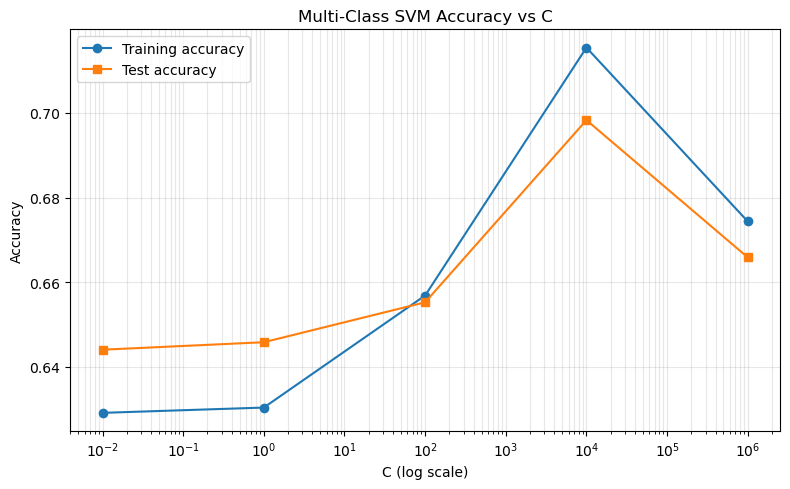

In [11]:
def plot_multiclass_svm_accuracy(Xtrain, ytrain, Xtest, ytest):

    # C values required for the experiment
    C_values = [0.01, 1, 100, 10000, 1000000]

    train_accuracies = []
    test_accuracies = []

    # Train a new multiclass SVM for each value of C
    for C in C_values:

        clf = MultiClassSVM(
            C=C,
            learning_rate=0.1,
            max_iter=1000,
            batch_size=64
        )

        # Train the one-vs-all SVM
        clf.fit(Xtrain, ytrain)

        # Predict training and test labels
        ytrain_pred = clf.predict(Xtrain)
        ytest_pred = clf.predict(Xtest)

        # Accuracy = proportion of correctly classified samples
        train_accuracy = np.mean(ytrain_pred == ytrain)
        test_accuracy = np.mean(ytest_pred == ytest)

        train_accuracies.append(train_accuracy)
        test_accuracies.append(test_accuracy)

        print(
            f"C = {C:<9g} "
            f"Train accuracy = {train_accuracy:.4f} "
            f"Test accuracy = {test_accuracy:.4f}"
        )

    # Plot accuracy against C
    plt.figure(figsize=(8, 5))

    plt.plot(
        C_values,
        train_accuracies,
        'o-',
        label='Training accuracy'
    )

    plt.plot(
        C_values,
        test_accuracies,
        's-',
        label='Test accuracy'
    )

    # C spans several orders of magnitude
    plt.xscale('log')

    plt.xlabel('C (log scale)')
    plt.ylabel('Accuracy')
    plt.title('Multi-Class SVM Accuracy vs C')

    plt.legend()
    plt.grid(True, which='both', alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_multiclass_svm_accuracy(
    Xtrain,
    ytrain,
    Xtest,
    ytest
)

## Confusion Matrix

Number of training samples: 4800, number of test samples: 1697
Labels:  [3 4 5 6 7 8 9]
Number of training samples in each class:
[  25  151 1566 2114  804  137    3]



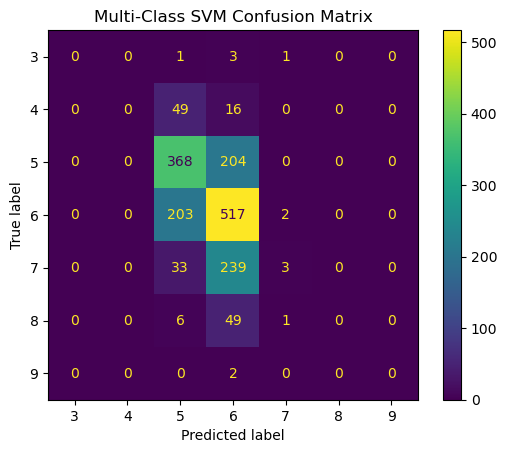

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


Xtrain, ytrain, Xtest, ytest = load_data(binary=False)
multiclass_svm = MultiClassSVM(C=1.0, learning_rate=0.1, max_iter=1000, batch_size=64)
multiclass_svm.fit(Xtrain, ytrain)

# Predict multiclass labels
y_pred = multiclass_svm.predict(Xtest)

# Build confusion matrix
cm = confusion_matrix(
    ytest,
    y_pred,
    labels=multiclass_svm.labels
)

# Plot it
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=multiclass_svm.labels
)

disp.plot()
plt.title("Multi-Class SVM Confusion Matrix")
plt.show()